# Exploratory Data Analysis (EDA) on Global Superstore Sales Dataset

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Global Superstore dataset to identify sales trends, customer behavior, product performance, and regional business insights. This analysis aims to transform raw data into meaningful insights that support better business decisions.

## Project Information

- **Intern Name:** S Pandi Durai
- **Internship:** Oasis Infobyte Data Analytics Internship
- **Task:** Task 1 – Exploratory Data Analysis (EDA) on Global Superstore Dataset

## Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook (VS Code)

## Workflow

1. Import Required Libraries
2. Load the Dataset
3. Dataset Overview
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Data Visualization
7. Business Insights
8. Conclusion

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
%matplotlib inline
df = pd.read_csv("dataset.csv")

df.head()


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## 2. Data Cleaning

Before performing exploratory analysis, the dataset is checked for missing values, duplicate records, incorrect data types, and other quality issues. This ensures that the analysis is based on clean and reliable data.

In [38]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Duplicate rows: 0

Data types:
order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object

## 3. Dataset Overview

In this section, the structure and basic characteristics of the dataset are examined. This includes the number of rows and columns, column names, data types, and summary statistics.

In [39]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (51290, 21)

Column Names:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      5

## 4. Date Conversion

The `order_date` and `ship_date` columns are converted from text format to datetime format. This enables time-based analysis such as monthly, quarterly, and yearly sales trends.

In [40]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="mixed",
    dayfirst=True
)
print(df[["order_date", "ship_date"]].dtypes)

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


## 5. Descriptive Statistics

Descriptive statistics are used to summarize the numerical features of the dataset. They provide information such as the count, mean, standard deviation, minimum, maximum, and quartile values, helping us understand the overall distribution of the data.

In [41]:
df.describe()

,order_date,ship_date,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,2.278766,0.212280,174.424113,57.296804,1.098931


In [42]:
original_df = pd.read_csv("dataset.csv")

df["sales"] = original_df["sales"]
df["sales"] = df["sales"].str.replace(",", "", regex=False)
df["sales"] = pd.to_numeric(df["sales"])
print("Sales data type:", df["sales"].dtype)
print("Missing sales values:", df["sales"].isnull().sum())

Sales data type: int64
Missing sales values: 0


## 6. Overall Business Performance

This section evaluates the overall performance of the business using key performance indicators (KPIs), including total sales, total profit, total number of orders, total quantity sold, and overall profit margin.

In [43]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $12,642,905.00
Total Profit: $1,469,034.82
Total Orders: 25,035
Total Quantity Sold: 178,312
Profit Margin: 11.62%


## 7. Yearly Sales Analysis

This analysis examines the total sales generated in each year to understand the overall growth or decline in business performance over time.

In [44]:
yearly_sales = df.groupby("year")["sales"].sum()

print(yearly_sales)

year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: sales, dtype: int64


### Yearly Sales Trend Visualization

A line chart is used to visualize changes in total sales over the years. This helps identify whether the business is experiencing growth or decline over time.

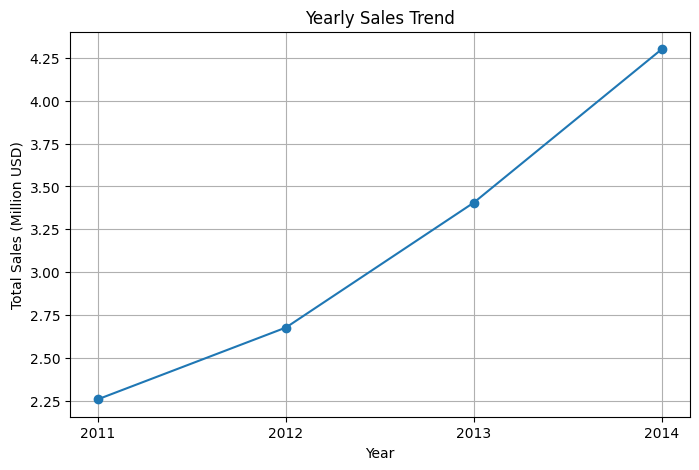

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values / 1_000_000,
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales (Million USD)")
plt.xticks(yearly_sales.index)
plt.grid(True)

plt.show()

## 8. Monthly Sales Analysis

This analysis examines total sales for each month over the complete dataset period. It helps identify sales trends, growth patterns, and fluctuations over time.

In [46]:
monthly_sales = (
    df.groupby(
        df["order_date"].dt.to_period("M")
    )["sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

order_date
2011-01-01     98902
2011-02-01     91152
2011-03-01    145726
2011-04-01    116927
2011-05-01    146762
Freq: MS, Name: sales, dtype: int64

### Monthly Sales Trend Visualization

A line chart is used to visualize monthly sales performance from 2011 to 2014. This helps identify long-term growth patterns, monthly fluctuations, and periods of high or low sales.

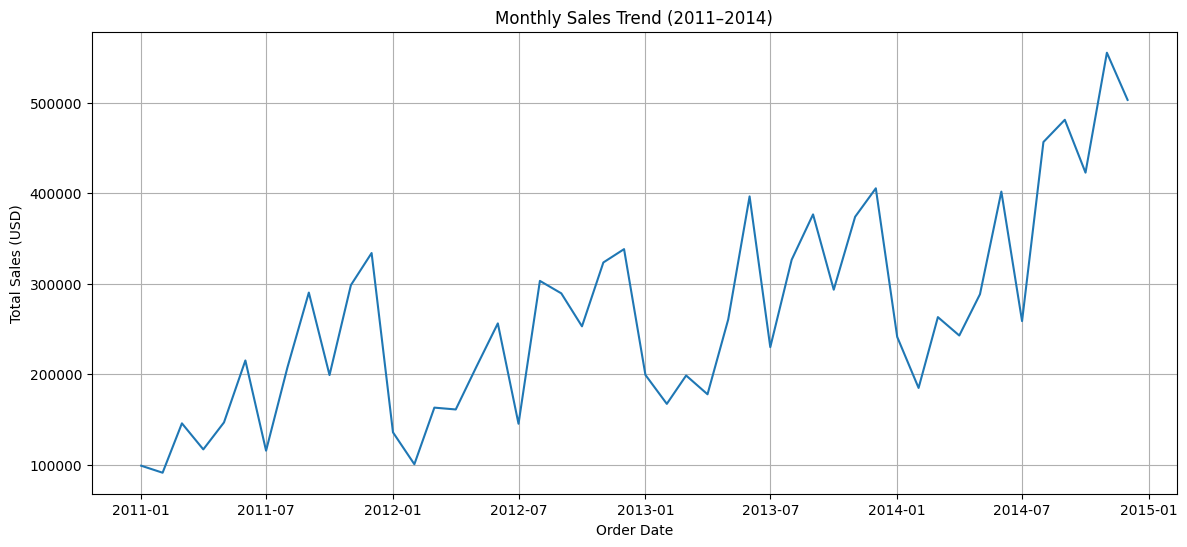

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Trend (2011–2014)")
plt.xlabel("Order Date")
plt.ylabel("Total Sales (USD)")
plt.grid(True)

plt.show()

## 9. Quarterly Sales Analysis

This analysis examines total sales for each quarter from 2011 to 2014. Quarterly analysis provides a broader view of sales performance than monthly analysis and helps identify seasonal patterns and high-performing business periods.

In [48]:
quarterly_sales = (
    df.groupby(
        df["order_date"].dt.to_period("Q")
    )["sales"]
    .sum()
)

print(quarterly_sales)

order_date
2011Q1     335780
2011Q2     478903
2011Q3     613318
2011Q4     831510
2012Q1     399388
2012Q2     625611
2012Q3     737795
2012Q4     914699
2013Q1     565035
2013Q2     834873
2013Q3     933057
2013Q4    1072895
2014Q1     689225
2014Q2     933028
2014Q3    1196537
2014Q4    1481251
Freq: Q-DEC, Name: sales, dtype: int64


### Quarterly Sales Trend Visualization

A line chart is used to visualize quarterly sales performance from 2011 to 2014. This helps identify broader sales trends and compare performance across different quarters.

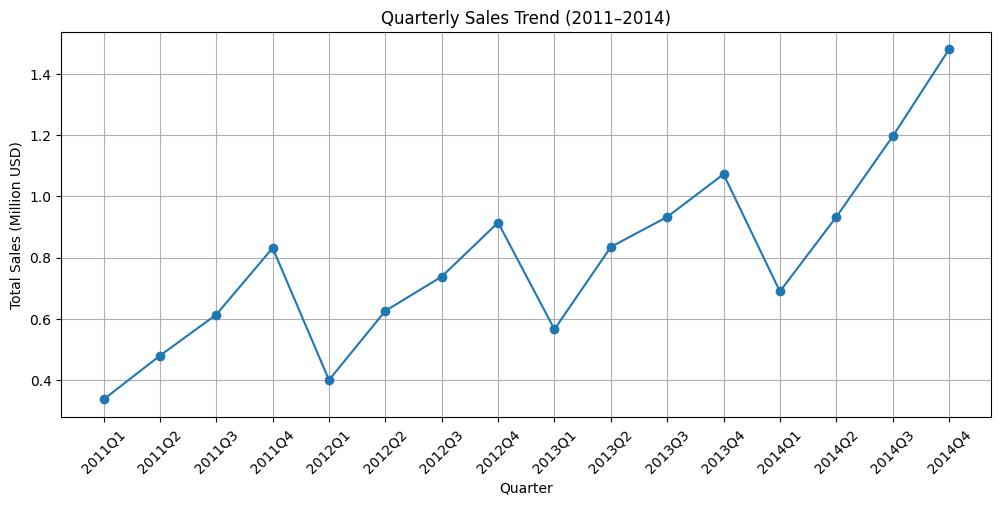

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values / 1_000_000,
    marker="o"
)

plt.title("Quarterly Sales Trend (2011–2014)")
plt.xlabel("Quarter")
plt.ylabel("Total Sales (Million USD)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 10. Sales by Category

This analysis compares total sales across the main product categories. It helps identify which category generates the highest revenue and contributes most to overall business sales.

In [50]:
category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64


### Sales by Category Visualization

A bar chart is used to compare total sales across product categories. This helps identify the category that generates the highest revenue.

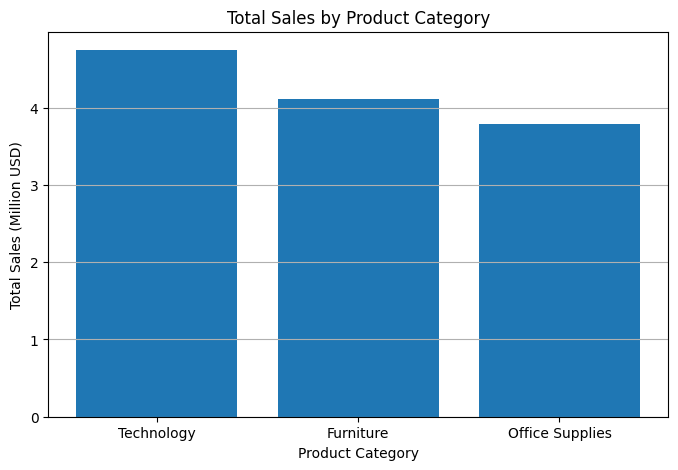

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values / 1_000_000
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales (Million USD)")
plt.grid(axis="y")

plt.show()

### Sales by Category Visualization

A bar chart is used to compare total sales across product categories. This helps identify the category that generates the highest revenue.

In [52]:
sub_category_sales = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(sub_category_sales)

sub_category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: sales, dtype: int64


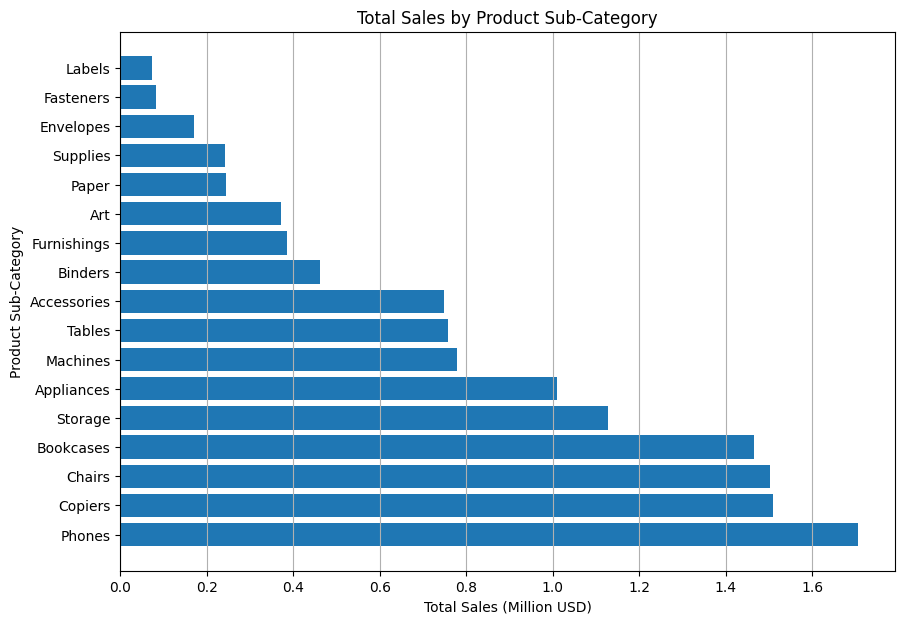

In [53]:
plt.figure(figsize=(10, 7))

plt.barh(
    sub_category_sales.index,
    sub_category_sales.values / 1_000_000
)

plt.title("Total Sales by Product Sub-Category")
plt.xlabel("Total Sales (Million USD)")
plt.ylabel("Product Sub-Category")
plt.grid(axis="x")

plt.show()

## 12. Profit by Category

This analysis compares the total profit generated by each product category. While sales measure revenue, profit shows how much the business actually earns after costs. A category with high sales does not necessarily generate the highest profit.

A bar chart is used because the product categories are separate groups, making it easy to compare their profitability.

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64


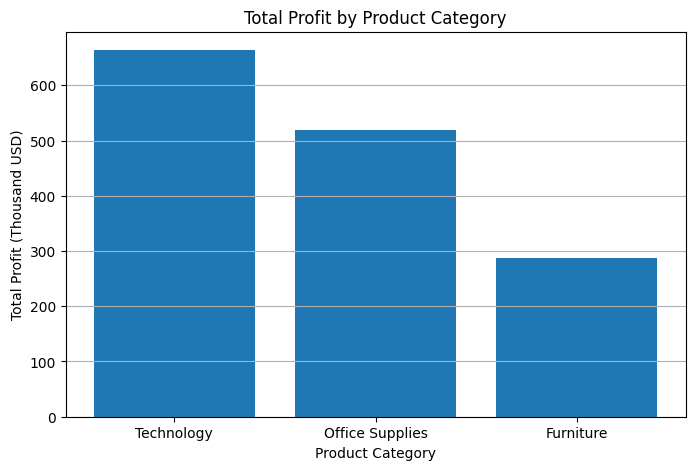

In [54]:
# Calculate total profit by category
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

# Visualize profit by category
plt.figure(figsize=(8, 5))

plt.bar(
    category_profit.index,
    category_profit.values / 1_000
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit (Thousand USD)")
plt.grid(axis="y")

plt.show()

## 13. Profit by Sub-Category

This analysis compares the total profit generated by each product sub-category. It helps identify the most profitable product groups and detect sub-categories that generate losses.

A horizontal bar chart is used because there are many sub-categories, and this format makes the category names and profit differences easier to compare.


sub_category
Tables         -64083.38870
Fasteners       11525.42410
Labels          15010.51200
Supplies        22583.26310
Envelopes       29601.11630
Furnishings     46967.42550
Art             57953.91090
Machines        58867.87300
Paper           59207.68270
Binders         72449.84600
Storage        108461.48980
Accessories    129626.30620
Appliances     141680.58940
Chairs         141973.79750
Bookcases      161924.41950
Phones         216717.00580
Copiers        258567.54818
Name: profit, dtype: float64


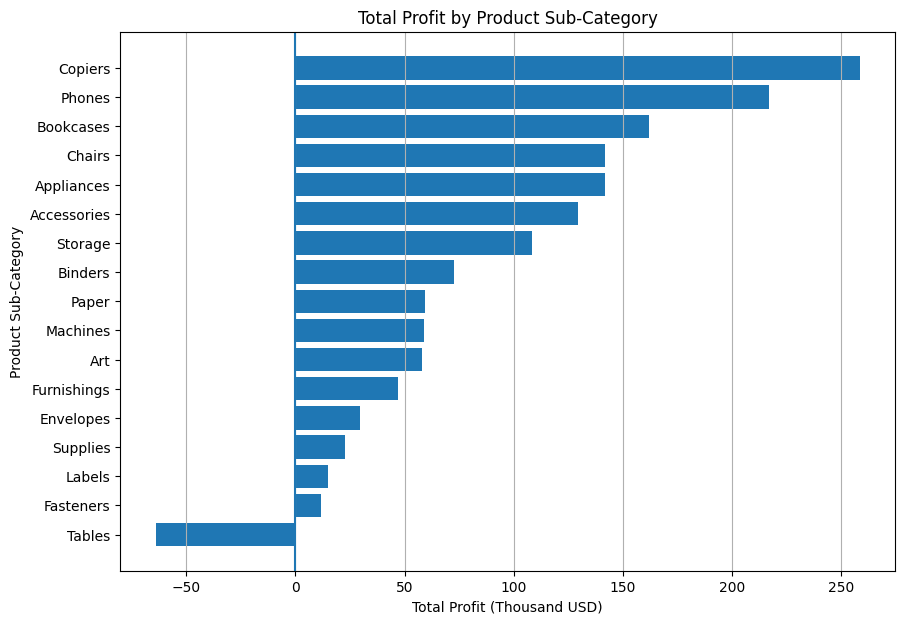

In [55]:
# Calculate total profit by sub-category
sub_category_profit = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values(ascending=True)
)

print(sub_category_profit)

# Visualize profit by sub-category
plt.figure(figsize=(10, 7))

plt.barh(
    sub_category_profit.index,
    sub_category_profit.values / 1_000
)

plt.title("Total Profit by Product Sub-Category")
plt.xlabel("Total Profit (Thousand USD)")
plt.ylabel("Product Sub-Category")
plt.axvline(0)
plt.grid(axis="x")

plt.show()

## 14. Sales and Profit by Market

This analysis compares total sales and total profit across different global markets. It helps identify markets that generate high revenue and determine whether those markets are also highly profitable.

A grouped bar chart is used to compare sales and profit across the same markets.

          sales        profit
market                       
APAC    3585833  437577.57900
EU      2938139  372829.74150
US      2297354  286397.02170
LATAM   2164687  221643.48708
EMEA     806184   43897.97100
Africa   783776   88871.63100
Canada    66932   17817.39000


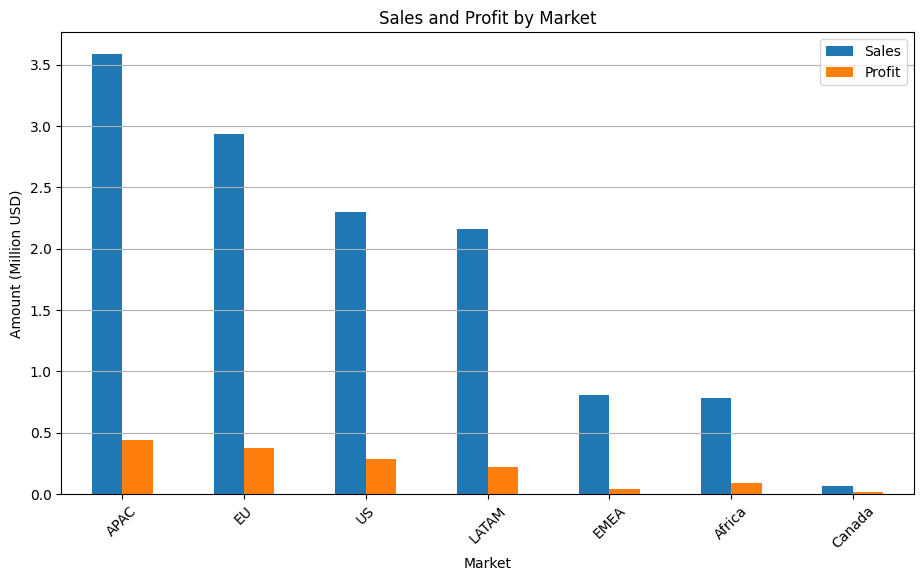

In [56]:
# Calculate total sales and profit by market
market_performance = (
    df.groupby("market")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
)

print(market_performance)

# Convert values to Million USD
market_performance_million = market_performance / 1_000_000

# Visualize sales and profit by market
market_performance_million.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Sales and Profit by Market")
plt.xlabel("Market")
plt.ylabel("Amount (Million USD)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.legend(["Sales", "Profit"])

plt.show()

## 15. Sales and Profit by Region

This analysis compares total sales and total profit across different regions. It helps identify high-performing regions, low-performing regions, and areas where high sales may not necessarily result in high profit.

A horizontal bar chart is used because the dataset contains several regions, making the region names and performance differences easier to compare.

                  sales        profit
region                               
Canada            66932   17817.39000
Caribbean        324281   34571.32104
East             678834   91522.78000
West             725514  108418.44890
Central Asia     752839  132480.18700
Africa           783776   88871.63100
EMEA             806184   43897.97100
North Asia       848349  165578.42100
Southeast Asia   884438   17852.32900
Oceania         1100207  121666.64200
North           1248192  194597.95252
South           1600960  140355.76618
Central         2822399  311403.98164


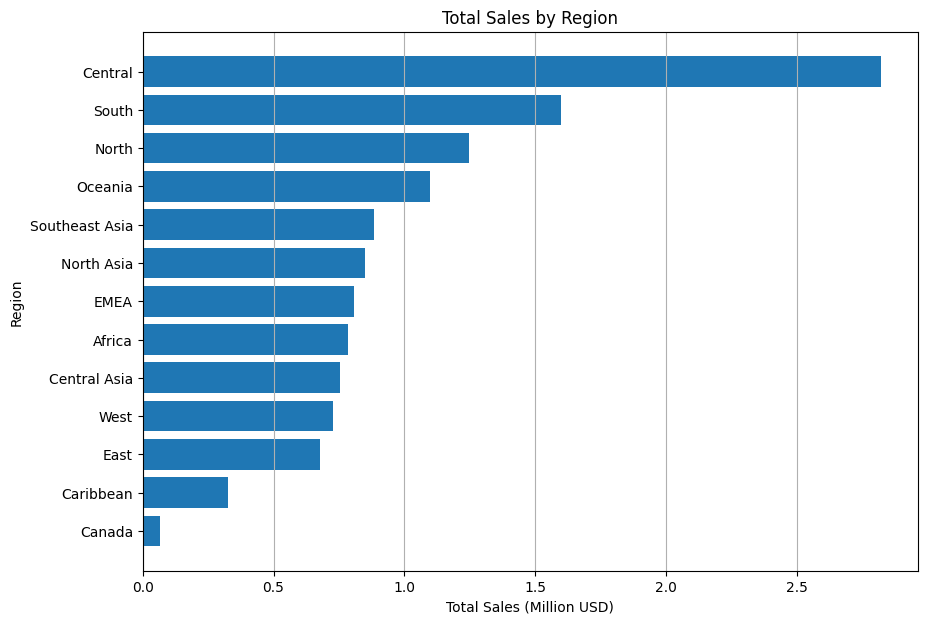

In [57]:
# Calculate total sales and profit by region
region_performance = (
    df.groupby("region")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=True)
)

print(region_performance)

# Visualize total sales by region
plt.figure(figsize=(10, 7))

plt.barh(
    region_performance.index,
    region_performance["sales"] / 1_000_000
)

plt.title("Total Sales by Region")
plt.xlabel("Total Sales (Million USD)")
plt.ylabel("Region")
plt.grid(axis="x")

plt.show()

## 16. Customer Segment Analysis

This analysis compares the total sales and profit generated by different customer segments. It helps identify which type of customer contributes the most to the business and whether the highest-selling segment is also the most profitable.

A bar chart is used because customer segments are separate categories, making their performance easy to compare.

               sales        profit
segment                           
Consumer     6508141  749239.78206
Corporate    3824808  442785.85866
Home Office  2309956  277009.18056


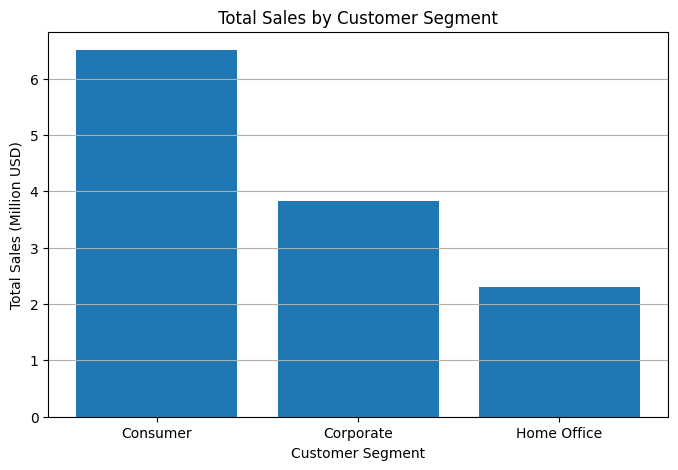

In [58]:
# Calculate sales and profit by customer segment
segment_performance = (
    df.groupby("segment")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
)

print(segment_performance)

# Visualize sales by customer segment
plt.figure(figsize=(8, 5))

plt.bar(
    segment_performance.index,
    segment_performance["sales"] / 1_000_000
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales (Million USD)")
plt.grid(axis="y")

plt.show()

## 17. Discount vs Profit Analysis

This analysis examines the relationship between discount and profit. It helps determine whether increasing discounts affects profitability and whether high discount levels are associated with losses.

A scatter plot is used because both discount and profit are numerical variables. Each point represents one record and shows the relationship between its discount level and profit.

Correlation between Discount and Profit: -0.316


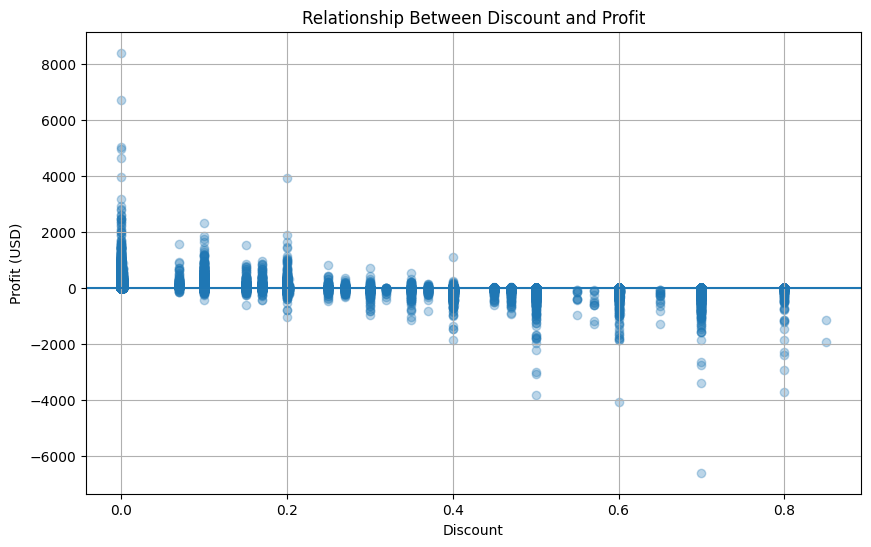

In [59]:
# Calculate the correlation between discount and profit
discount_profit_correlation = df["discount"].corr(df["profit"])

print(
    "Correlation between Discount and Profit:",
    round(discount_profit_correlation, 3)
)

# Visualize the relationship
plt.figure(figsize=(10, 6))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.3
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit (USD)")
plt.axhline(0)
plt.grid(True)

plt.show()

## 18. Top Products by Sales

This analysis identifies the products that generate the highest total sales. It helps the business understand which individual products contribute the most to overall revenue.

A horizontal bar chart is used because product names are long and easier to read vertically. Only the top 10 products are displayed to keep the visualization clear.

product_name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: sales, dtype: int64


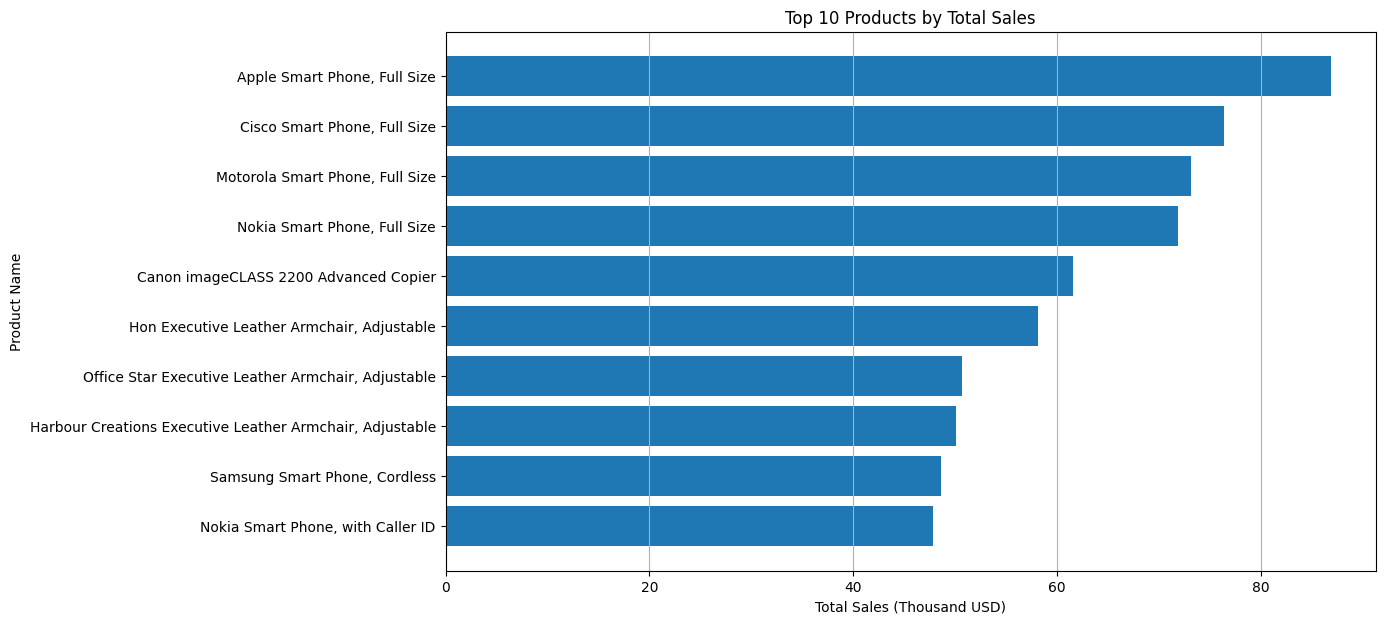

In [60]:
# Calculate total sales for each product
top_products_sales = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_sales)

# Sort for horizontal bar chart
top_products_sales = top_products_sales.sort_values()

# Visualize top 10 products by sales
plt.figure(figsize=(12, 7))

plt.barh(
    top_products_sales.index,
    top_products_sales.values / 1_000
)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales (Thousand USD)")
plt.ylabel("Product Name")
plt.grid(axis="x")

plt.show()

## 19. Top Products by Profit

This analysis identifies the products that generate the highest total profit. It helps determine which individual products contribute the most to business profitability.

A horizontal bar chart is used because product names are long and easier to read in this format. Only the top 10 products are displayed to keep the visualization clear.

product_name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: profit, dtype: float64


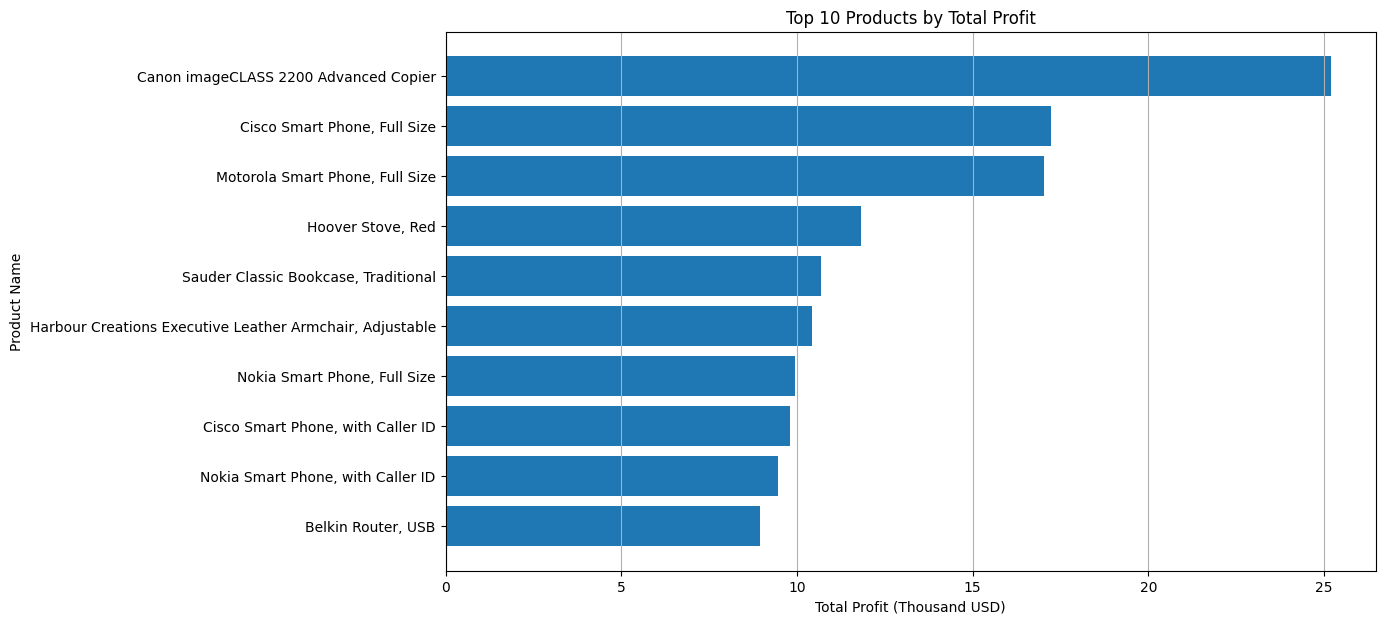

In [61]:
# Calculate total profit for each product
top_products_profit = (
    df.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_profit)

# Sort for horizontal bar chart
top_products_profit = top_products_profit.sort_values()

# Visualize top 10 products by profit
plt.figure(figsize=(12, 7))

plt.barh(
    top_products_profit.index,
    top_products_profit.values / 1_000
)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Total Profit (Thousand USD)")
plt.ylabel("Product Name")
plt.grid(axis="x")

plt.show()

## 20. Shipping Mode Analysis

This analysis examines the number of orders handled through each shipping mode. It helps identify the shipping method most frequently used by customers.

A bar chart is used because shipping modes are separate categories, making their usage easy to compare.

ship_mode
Standard Class    15154
Second Class       5119
First Class        3821
Same Day           1347
Name: order_id, dtype: int64


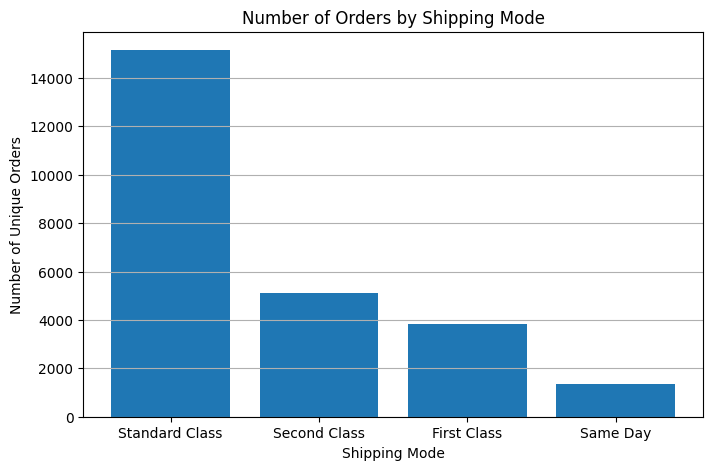

In [62]:
# Count unique orders for each shipping mode
ship_mode_orders = (
    df.groupby("ship_mode")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(ship_mode_orders)

# Visualize orders by shipping mode
plt.figure(figsize=(8, 5))

plt.bar(
    ship_mode_orders.index,
    ship_mode_orders.values
)

plt.title("Number of Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Unique Orders")
plt.grid(axis="y")

plt.show()

## 21. Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. It helps identify whether variables such as sales, quantity, discount, profit, and shipping cost tend to increase or decrease together.

A correlation heatmap is used to display these relationships clearly. Correlation values range from -1 to +1:

- **+1:** Strong positive relationship
- **0:** Little or no linear relationship
- **-1:** Strong negative relationship

                  sales  quantity  discount    profit  shipping_cost
sales          1.000000  0.313580 -0.086728  0.485944       0.768075
quantity       0.313580  1.000000 -0.019875  0.104743       0.272649
discount      -0.086728 -0.019875  1.000000 -0.316375      -0.079056
profit         0.485944  0.104743 -0.316375  1.000000       0.357033
shipping_cost  0.768075  0.272649 -0.079056  0.357033       1.000000


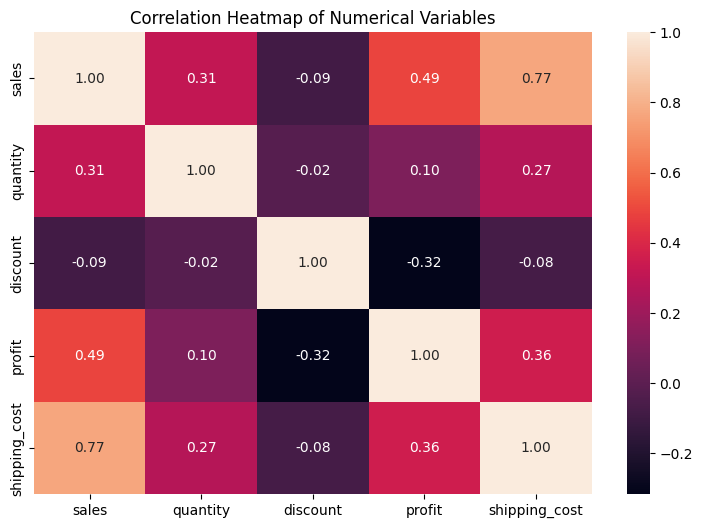

In [63]:
# Select relevant numerical columns
numeric_columns = df[
    ["sales", "quantity", "discount", "profit", "shipping_cost"]
]

# Calculate correlation
correlation_matrix = numeric_columns.corr()

print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

## 22. Order Priority Analysis

This analysis examines the number of unique orders across different order priority levels. It helps understand how frequently orders are classified as Critical, High, Medium, or Low priority.

A bar chart is used because order priority levels are separate categories, making their order volumes easy to compare.

order_priority
Medium      14484
High         7767
Critical     1967
Low          1212
Name: order_id, dtype: int64


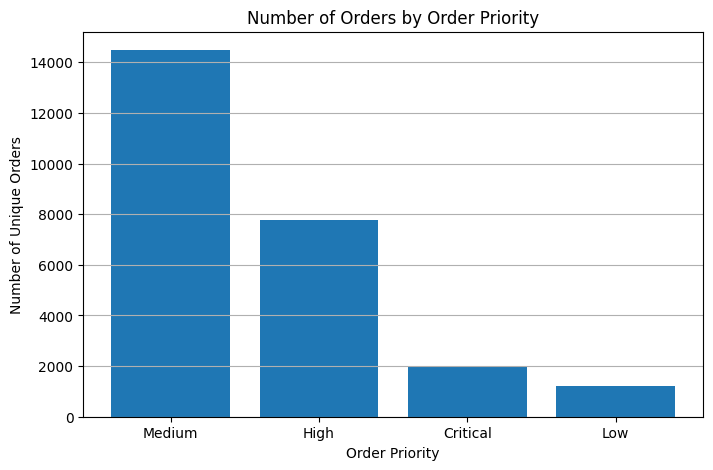

In [64]:
# Count unique orders by order priority
priority_orders = (
    df.groupby("order_priority")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(priority_orders)

# Visualize orders by priority
plt.figure(figsize=(8, 5))

plt.bar(
    priority_orders.index,
    priority_orders.values
)

plt.title("Number of Orders by Order Priority")
plt.xlabel("Order Priority")
plt.ylabel("Number of Unique Orders")
plt.grid(axis="y")

plt.show()

## 23. Key Business Insights

The exploratory data analysis revealed several important findings about the Global Superstore's performance:

- **2014 recorded the highest sales**, generating approximately **$4.30 million**, indicating strong business growth over the analyzed period.

- **Technology was the highest-selling product category**, generating approximately **$4.74 million in sales**.

- **Technology was also the most profitable category**, generating approximately **$663.78 thousand in profit**, showing strong performance in both revenue and profitability.

- **Tables was the only loss-making sub-category**, with a total loss of approximately **$64.08 thousand**. Its pricing, discount strategy, product costs, and shipping expenses require further investigation.

- **APAC was the highest-performing market by sales**, generating approximately **$3.59 million**.

- **Central was the highest-performing region by sales**, generating approximately **$2.82 million**.

- The **Consumer segment** generated the highest sales, contributing approximately **$6.51 million**, making it the largest revenue-generating customer segment.

- The correlation between **discount and profit was -0.316**, indicating a moderate negative relationship. Higher discounts generally tend to be associated with lower profitability.

- The correlation between **sales and shipping cost was 0.768**, indicating a strong positive relationship. Higher-value sales tend to be associated with higher shipping costs.

- **Standard Class was the most frequently used shipping mode**, with **15,154 unique orders**.

- **Medium was the most common order priority**, with **14,484 unique orders**.

Overall, the business showed strong sales growth, particularly in the **Technology category** and **Consumer segment**. However, the loss generated by the **Tables sub-category** and the negative relationship between **discounts and profit** require management attention.

## 24. Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are proposed:

- Continue investing in the **Technology category**, as it generates both the highest sales and the highest profit.

- Investigate the **Tables sub-category**, which generated an overall loss of approximately **$64.08 thousand**. Pricing, discount levels, product costs, and shipping expenses should be reviewed to identify the causes of the loss.

- Review the current **discount strategy**, as the negative correlation between discount and profit suggests that higher discounts are generally associated with lower profitability. Discounts should be applied strategically rather than excessively.

- Strengthen business operations and marketing efforts in the **APAC market** and **Central region**, as they generate the highest sales in their respective geographical groups.

- Continue focusing on the **Consumer segment**, which is the largest contributor to total sales, while also exploring opportunities to increase sales from Corporate and Home Office customers.

- Monitor and optimize **shipping expenses**, as sales and shipping cost have a strong positive relationship. Cost-efficient shipping strategies should be considered for high-value orders to protect profitability.

- Maintain sufficient operational capacity for **Standard Class shipping**, as it is the most frequently used shipping mode.

- Ensure efficient processing of **Medium-priority orders**, as they represent the largest share of unique orders.

---

## 25. Conclusion

The exploratory data analysis of the Global Superstore dataset provided a comprehensive understanding of sales performance, profitability, product performance, customer segments, geographical trends, discounts, and shipping operations.

The analysis showed that sales reached their highest level in **2014**. **Technology** was the strongest category in both sales and profit, while **Tables** was the only loss-making sub-category. The **Consumer segment** generated the highest sales, **APAC** was the leading market, and **Central** was the highest-performing region by sales.

The correlation analysis revealed that higher discounts tend to be associated with lower profits, while higher sales values are strongly associated with higher shipping costs. These findings highlight the importance of managing discounts carefully, controlling shipping expenses, supporting high-performing products and markets, and addressing loss-making product groups.

Overall, the analysis demonstrates how exploratory data analysis can transform raw transactional data into meaningful business insights and support better data-driven decision-making.